In [1]:
import os
os.chdir('/workspace/bbc575b4-2c28-481d-b118-cd6e0285df00')
print(os.listdir('.'))


['zeta_zeros_5000_dps50.npy', '.kernel_llm_logs_1.txt', '.config', '.prompts', 'ldh_def.py', 'weil_J_sweep_results.json', 'memory', 'weil_J_sweep_ldh_results.json']


In [2]:
import json
with open('weil_J_sweep_results.json') as f:
 r24 = json.load(f)
with open('weil_J_sweep_ldh_results.json') as f:
 r28 = json.load(f)
print(json.dumps(r24, indent=2)[:3000])
print('---')
print(json.dumps(r28, indent=2)[:3000])


{
 "description": "J-sweep of Weil quadratic form Q = M_zeros - M_arith at (T0=46.13, sigma=1.0). Tests how lambda_min scales with basis dimension J for the deformed zeta (first 20 zeros shifted by delta=0.05) versus undeformed zeta.",
 "parameters": {
 "T0": 46.1347251417347,
 "sigma": 1.0,
 "prime_bound": 1000,
 "half_window": 20.0,
 "delta": 0.05,
 "zeros_in_window": 12,
 "shifted_zeros_in_window": 12,
 "test_basis": "h_i(t) = ((t-T0)/sigma)^i * exp(-((t-T0)/sigma)^2 / 2), i=0..J-1",
 "M_zeros_formula": "for zero at 1/2+beta+i*gamma: contribute Re[v v^T] with v = h(\u00b1gamma - i*beta) (functional-equation pair, no conjugation in outer product)",
 "M_arith_formula": "sum_{p, k: p^k <= prime_bound} (log p)/sqrt(p^k) * [h(k log p) h(k log p)^T + h(-k log p) h(-k log p)^T]",
 "precision": "mpmath at dps=80; eigenvalues via mpmath then float conversion"
 },
 "J_values": [
 4,
 8,
 12,
 16,
 20
 ],
 "lambda_min_zeta": [
 7.782845486781997e-11,
 1.1176654040527063e-70,
 -9.26027356607411

In [3]:
print(json.dumps(r28['parameters'], indent=2))


{
 "T0": "85.7",
 "sigma": "2.0",
 "half_window": "40.0",
 "prime_bound": 1000,
 "dps": 80,
 "M_zeros_formula": "for zero at 1/2+beta+i*gamma: contribute Re[v v^T] with v = h(\u00b1gamma - i*beta) (functional-equation pair, no conjugation)",
 "M_arith_formula": "sum_{p,k: p^k<=prime_bound} Re[Lambda(p^k)]/sqrt(p^k) * [h(k log p) h(k log p)^T + h(-k log p) h(-k log p)^T]",
 "Lambda_chi": "Lambda_chi(p^k) = chi(p)^k * log(p) (complex; we use Re part)",
 "Lambda_DH": "Lambda_DH(p^k) from recurrence on Dirichlet coeffs c_n = A*chi(n) + B*chibar(n) of L_DH (real)",
 "L_DH_off_critical_zero": {
 "gamma": "85.699348485377592171929267708941729037987829423407575924765024463854574584004397",
 "beta_pair": [
 "0.30851718245663738555335196060684412785067026830501462250439870858155011800810091",
 "-0.30851718245663738555335196060684412785067026830501462250439870858155011800810091"
 ]
 },
 "L_DH_critical_zeros_in_window": 49,
 "L_chi_critical_zeros_in_window": 53
}


In [4]:
print(json.dumps({k: r28[k] for k in r28 if k != 'analysis'}, indent=2)[:2500])


{
 "parameters": {
 "T0": "85.7",
 "sigma": "2.0",
 "half_window": "40.0",
 "prime_bound": 1000,
 "dps": 80,
 "M_zeros_formula": "for zero at 1/2+beta+i*gamma: contribute Re[v v^T] with v = h(\u00b1gamma - i*beta) (functional-equation pair, no conjugation)",
 "M_arith_formula": "sum_{p,k: p^k<=prime_bound} Re[Lambda(p^k)]/sqrt(p^k) * [h(k log p) h(k log p)^T + h(-k log p) h(-k log p)^T]",
 "Lambda_chi": "Lambda_chi(p^k) = chi(p)^k * log(p) (complex; we use Re part)",
 "Lambda_DH": "Lambda_DH(p^k) from recurrence on Dirichlet coeffs c_n = A*chi(n) + B*chibar(n) of L_DH (real)",
 "L_DH_off_critical_zero": {
 "gamma": "85.699348485377592171929267708941729037987829423407575924765024463854574584004397",
 "beta_pair": [
 "0.30851718245663738555335196060684412785067026830501462250439870858155011800810091",
 "-0.30851718245663738555335196060684412785067026830501462250439870858155011800810091"
 ]
 },
 "L_DH_critical_zeros_in_window": 49,
 "L_chi_critical_zeros_in_window": 53
 },
 "J_values": [


In [5]:
import numpy as np
zeros_str = np.load('zeta_zeros_5000_dps50.npy')
print(zeros_str.shape, zeros_str.dtype, zeros_str[:5])


(5000,) <U60 ['14.134725141734693790457251983562470270784257115699'
 '21.022039638771554992628479593896902777334340524903'
 '25.010857580145688763213790992562821818659549672558'
 '30.424876125859513210311897530584091320181560023715'
 '32.935061587739189690662368964074903488812715603517']


In [6]:
import mpmath
mpmath.mp.dps = 80

# Setup parameters - exactly per r24
T0 = mpmath.mpf('46.1347251417347')
sigma = mpmath.mpf(1)
half_window = mpmath.mpf(20)
delta = mpmath.mpf('0.05')
prime_bound = 1000

# Load zeros and filter window
gammas_all = [mpmath.mpf(s) for s in zeros_str]
# Window: T0 ± half_window
window_lo = T0 - half_window
window_hi = T0 + half_window
gammas_window = [g for g in gammas_all if window_lo <= g <= window_hi]
print("zeros in window:", len(gammas_window))

# Find zero closest to T0
diffs = [abs(g - T0) for g in gammas_window]
idx_min = min(range(len(gammas_window)), key=lambda i: diffs[i])
print(f"Closest zero index in window: {idx_min}, value = {gammas_window[idx_min]}")
print(f"This is gamma_13 = {gammas_all[12]}")
# gamma_13 is gammas_all[12] (1-indexed)
print(f"index in full list:", gammas_all.index(gammas_window[idx_min]))


zeros in window: 12
Closest zero index in window: 5, value = 48.005150881167159727942472749427516041686844001144
This is gamma_13 = 59.347044002602353079653648674992219031098772806467
index in full list: 8


In [7]:
# Wait - the problem says gamma_13 ≈ 46.1347, but gammas_all[12] = 59.34... let me check
for i in range(20):
 print(i+1, gammas_all[i])


1 14.134725141734693790457251983562470270784257115699
2 21.022039638771554992628479593896902777334340524903
3 25.010857580145688763213790992562821818659549672558
4 30.424876125859513210311897530584091320181560023715
5 32.935061587739189690662368964074903488812715603517
6 37.586178158825671257217763480705332821405597350831
7 40.918719012147495187398126914633254395726165962777
8 43.327073280914999519496122165406805782645668371837
9 48.005150881167159727942472749427516041686844001144
10 49.773832477672302181916784678563724057723178299677
11 52.970321477714460644147296608880990063825017888821
12 56.446247697063394804367759476706127552782264471717
13 59.347044002602353079653648674992219031098772806467
14 60.831778524609809844259901824524003802910090451219
15 65.112544048081606660875054253183705029348149295167
16 67.079810529494173714478828896522216770107144951746
17 69.546401711173979252926857526554738443012474209602
18 72.067157674481907582522107969826168390480906621457
19 75.7046906990839

In [8]:
# So actually the closest zero to T0=46.13 is gamma_9 = 48.005, not 46.1347
# But the hypothesis says γ₁₃ ≈ 46.1347 - that's incorrect labeling but T0=46.13 matches the r24 parameter
# Looking again: T0 = 46.1347 - that's actually 14.134... * pi or something close. Hmm
# Actually note T0=46.13 was chosen perhaps as midpoint, not as a zero
# Let me proceed: the hypothesis says "shift only the single zero closest to T₀" -- that's the closest zero in window
# Which is gammas_window[5] = 48.005 (which is gamma_9 in the full list)
# Actually wait - let me recompute. Window center T0=46.1347. The closest zero is 48.005 (idx 5 in window = gamma_9 in full list)
# But gamma_8 = 43.327 which is |43.327 - 46.13| = 2.81, while |48.005 - 46.13| = 1.87
# So gamma_9 is correct as closest.
# The hypothesis description is incorrect about "γ₁₃" but I'll follow the directive: shift the single zero closest to T0
print("Closest zero to T0:", gammas_window[5])
print("Distance:", abs(gammas_window[5] - T0))
print("All distances to T0:")
for i, g in enumerate(gammas_window):
 print(f" window[{i}] = {float(g):.4f}, dist = {float(abs(g-T0)):.4f}")


Closest zero to T0: 48.005150881167159727942472749427516041686844001144
Distance: 1.870425739432459727942472749427516041686844001144
All distances to T0:
 window[0] = 30.4249, dist = 15.7098
 window[1] = 32.9351, dist = 13.1997
 window[2] = 37.5862, dist = 8.5485
 window[3] = 40.9187, dist = 5.2160
 window[4] = 43.3271, dist = 2.8077
 window[5] = 48.0052, dist = 1.8704
 window[6] = 49.7738, dist = 3.6391
 window[7] = 52.9703, dist = 6.8356
 window[8] = 56.4462, dist = 10.3115
 window[9] = 59.3470, dist = 13.2123
 window[10] = 60.8318, dist = 14.6971
 window[11] = 65.1125, dist = 18.9778


In [9]:
# Now let me build the Weil quadratic form per r24/r28 conventions
# Test basis: h_i(t) = ((t-T0)/sigma)^i * exp(-((t-T0)/sigma)^2 / 2), i=0..J-1
# Note: zeros are at 1/2 + i*gamma typically, so the "value" passed to h is on the critical line as v = h(gamma).
# For a zero at 1/2 + beta + i*gamma: v_i = h_i(gamma - i*beta), and we sum Re[v v^T] (no conjugation, non-Hermitian construction) for both ±gamma functional-equation pair.

from mpmath import mpc, mpf, exp, log, sqrt, mp, matrix
import mpmath as mp_

# Helper: compute v_J(x) where x could be complex; v_j = ((x-T0)/sigma)^j * exp(-((x-T0)/sigma)^2 / 2)
def h_vec(x, T0, sigma, J):
 z = (x - T0) / sigma
 base = mp_.exp(-z*z / 2)
 v = mp_.matrix(J, 1)
 pw = mpc(1)
 for j in range(J):
 v[j,0] = pw * base
 pw = pw * z
 return v

# For a zero at 1/2 + beta + i*gamma, contribute Re[v v^T] for both v at (gamma - i*beta) and (-gamma - i*beta)
def add_zero_contribution(M, gamma, beta, T0, sigma, J):
 for sign in (mpf(1), mpf(-1)):
 x = sign * gamma - mpc(0, 1) * beta # i.e., sign*gamma - i*beta -> complex
 # Wait the formula says v = h(±gamma - i*beta). Let me re-read.
 # "v = h(±gamma - i*beta) (functional-equation pair, no conjugation in outer product)"
 # So arg = ±gamma - i*beta (where i is sqrt(-1))
 arg = mpc(sign * gamma, -beta) # sign*gamma + i*(-beta) = sign*gamma - i*beta
 v = h_vec(arg, T0, sigma, J)
 # outer product v v^T (no conjugate)
 for a in range(J):
 for b in range(J):
 M[a,b] += (v[a,0] * v[b,0]).real

# Build M_arith for zeta (sum over primes p^k <= prime_bound: (log p)/sqrt(p^k) * [h(k log p) h(k log p)^T + h(-k log p) h(-k log p)^T])
def get_prime_powers(bound):
 # primes up to bound
 sieve = [True] * (bound + 1)
 sieve[0] = sieve[1] = False
 for i in range(2, int(bound**0.5)+1):
 if sieve[i]:
 for j in range(i*i, bound+1, i):
 sieve[j] = False
 primes = [i for i in range(2, bound+1) if sieve[i]]
 pps = [] # list of (p, k, p^k)
 for p in primes:
 pk = p
 k = 1
 while pk <= bound:
 pps.append((p, k, pk))
 k += 1
 pk *= p
 return pps

prime_powers = get_prime_powers(prime_bound)
print(f"# prime powers <= {prime_bound}: {len(prime_powers)}")


# prime powers <= 1000: 193


In [10]:
def build_M_arith_zeta(J, T0, sigma, prime_powers):
 M = mp_.matrix(J, J)
 for (p, k, pk) in prime_powers:
 logp = mp_.log(p)
 coef = logp / mp_.sqrt(pk)
 klogp = k * logp
 for s_sign in (mpf(1), mpf(-1)):
 x = s_sign * klogp # real
 v = h_vec(x, T0, sigma, J)
 for a in range(J):
 for b in range(J):
 M[a,b] += coef * (v[a,0] * v[b,0]).real
 return M

def build_M_zeros(zeros_list, T0, sigma, J):
 # zeros_list: list of (gamma, beta) pairs
 M = mp_.matrix(J, J)
 for (gamma, beta) in zeros_list:
 add_zero_contribution(M, gamma, beta, T0, sigma, J)
 return M

def min_max_eig(M):
 n = M.rows
 # Symmetrize? It should already be symmetric (since Re[v v^T] is real symmetric? 
 # Actually v v^T is symmetric (not Hermitian), Re[.] preserves symmetry.
 # Use mpmath eigsy for symmetric
 # Convert to numpy if J small? Let's use mpmath for high precision
 try:
 eigs = mp_.eigsy(M, eigvals_only=True)
 eigs_float = [float(e) for e in eigs]
 return min(eigs_float), max(eigs_float)
 except Exception as e:
 # fallback
 eigs = mp_.eig(M, left=False, right=False)
 eigs_float = [float(e.real) for e in eigs]
 return min(eigs_float), max(eigs_float)

# Quick test with small J
J_test = 4
M_arith = build_M_arith_zeta(J_test, T0, sigma, prime_powers)
zeros_crit = [(g, mpf(0)) for g in gammas_window]
M_zeros = build_M_zeros(zeros_crit, T0, sigma, J_test)
Q = M_zeros - M_arith
lmin, lmax = min_max_eig(Q)
print(f"J=4 crit-only: lmin={lmin:.6e}, lmax={lmax:.6e}")
print(f"r24 reference: lmin={r24['lambda_min_zeta'][0]:.6e}, lmax={r24['lambda_max_zeta'][0]:.6e}")


J=4 crit-only: lmin=7.782845e-11, lmax=1.905038e+00
r24 reference: lmin=7.782845e-11, lmax=1.905038e+00


In [11]:
# Reproduction matches. Now build single-zero shift: only the zero closest to T0 gets beta=delta
# All other zeros remain on critical line (beta=0)

def make_single_shift_zeros(gammas_window, idx_shift, delta):
 zeros_list = []
 for i, g in enumerate(gammas_window):
 beta = delta if i == idx_shift else mpf(0)
 zeros_list.append((g, beta))
 return zeros_list

idx_closest = 5 # window[5] = closest to T0
zeros_single_shift = make_single_shift_zeros(gammas_window, idx_closest, delta)
print("Shifted zero:", zeros_single_shift[idx_closest])
print("All others have beta=0")


Shifted zero: (mpf('48.005150881167159727942472749427516041686844001143999999999999999999999999999999992'), mpf('0.050000000000000000000000000000000000000000000000000000000000000000000000000000000026'))
All others have beta=0


In [12]:
# Now do the J-sweep. Need to be efficient. Build for J in {4,8,12,16,20}
# We can build the largest J=20 then take leading principal submatrices? Yes.

import time

J_max = 20
J_values = [4, 8, 12, 16, 20]

t0 = time.time()
M_arith_full = build_M_arith_zeta(J_max, T0, sigma, prime_powers)
print(f"M_arith built in {time.time()-t0:.1f}s")

t0 = time.time()
M_zeros_single_full = build_M_zeros(zeros_single_shift, T0, sigma, J_max)
print(f"M_zeros (single shift) built in {time.time()-t0:.1f}s")

# Also build crit-only for sanity check (should match r24 zeta crit values)
t0 = time.time()
M_zeros_crit_full = build_M_zeros([(g, mpf(0)) for g in gammas_window], T0, sigma, J_max)
print(f"M_zeros (crit) built in {time.time()-t0:.1f}s")


M_arith built in 1.1s
M_zeros (single shift) built in 0.1s
M_zeros (crit) built in 0.1s


In [13]:
def submatrix(M, J):
 Mp = mp_.matrix(J, J)
 for i in range(J):
 for j in range(J):
 Mp[i,j] = M[i,j]
 return Mp

lambda_min_single = []
lambda_max_single = []
lambda_min_crit = []
lambda_max_crit = []

for J in J_values:
 M_a = submatrix(M_arith_full, J)
 M_z_single = submatrix(M_zeros_single_full, J)
 M_z_crit = submatrix(M_zeros_crit_full, J)
 Q_single = M_z_single - M_a
 Q_crit = M_z_crit - M_a
 t0 = time.time()
 lmin_s, lmax_s = min_max_eig(Q_single)
 lmin_c, lmax_c = min_max_eig(Q_crit)
 print(f"J={J}: single lmin={lmin_s:.4e}, lmax={lmax_s:.4e} | crit lmin={lmin_c:.4e}, lmax={lmax_c:.4e} ({time.time()-t0:.1f}s)")
 lambda_min_single.append(lmin_s)
 lambda_max_single.append(lmax_s)
 lambda_min_crit.append(lmin_c)
 lambda_max_crit.append(lmax_c)


J=4: single lmin=-1.7589e-04, lmax=1.9106e+00 | crit lmin=7.7828e-11, lmax=1.9050e+00 (0.0s)
J=8: single lmin=-5.4692e-03, lmax=1.0707e+03 | crit lmin=1.1177e-70, lmax=1.0725e+03 (0.0s)
J=12: single lmin=-3.8408e-01, lmax=6.7517e+06 | crit lmin=-3.0431e-82, lmax=6.7538e+06 (0.0s)
J=16: single lmin=-5.6901e+01, lmax=1.4241e+11 | crit lmin=-1.9690e-79, lmax=1.4241e+11 (0.0s)
J=20: single lmin=-1.7380e+03, lmax=6.5591e+15 | crit lmin=-1.0782e-75, lmax=6.5591e+15 (0.1s)


In [14]:
# Compare. Crit-only matches r24 reference. Single-shift has milder growth than r24 zeta_delta (multi-zero).
# Compute log-log slopes
import math

def log_log_slopes(Js, vals):
 slopes = []
 for i in range(1, len(Js)):
 if vals[i-1] == 0 or vals[i] == 0:
 slopes.append(None)
 continue
 a = math.log(abs(vals[i])) - math.log(abs(vals[i-1]))
 b = math.log(Js[i]) - math.log(Js[i-1])
 slopes.append(a/b)
 return slopes

# r24 zeta_delta (multi-zero, 12 zeros all shifted by delta=0.05)
zd_multi = r24['lambda_min_zeta_delta']
# r28 L_DH off-critical
ldh = r28['lambda_min_ldh_offcrit']
# single shift (this run)
zd_single = lambda_min_single

print("J values:", J_values)
print(f"{'J_from':>6} {'J_to':>4} {'multi-zeta':>12} {'single-zeta':>12} {'L_DH':>12}")
slopes_multi = log_log_slopes(J_values, zd_multi)
slopes_single = log_log_slopes(J_values, zd_single)
slopes_ldh = log_log_slopes(J_values, ldh)
for i in range(len(slopes_multi)):
 sm = f"{slopes_multi[i]:.3f}" if slopes_multi[i] else "N/A"
 ss = f"{slopes_single[i]:.3f}" if slopes_single[i] else "N/A"
 sl = f"{slopes_ldh[i]:.3f}" if slopes_ldh[i] else "N/A"
 print(f"{J_values[i]:>6} {J_values[i+1]:>4} {sm:>12} {ss:>12} {sl:>12}")

print("\nValues |lmin|:")
print(f"{'J':>4} {'|multi|':>15} {'|single|':>15} {'|LDH|':>15}")
for i, J in enumerate(J_values):
 print(f"{J:>4} {abs(zd_multi[i]):>15.4e} {abs(zd_single[i]):>15.4e} {abs(ldh[i]):>15.4e}")


J values: [4, 8, 12, 16, 20]
J_from J_to multi-zeta single-zeta L_DH
 4 8 5.973 4.959 -3.462
 8 12 16.746 10.486 0.470
 12 16 29.925 17.374 1.405
 16 20 50.583 15.323 0.924

Values |lmin|:
 J |multi| |single| |LDH|
 4 1.8128e-04 1.7589e-04 1.7293e-01
 8 1.1384e-02 5.4692e-03 1.5690e-02
 12 1.0119e+01 3.8408e-01 1.8983e-02
 16 5.5462e+04 5.6901e+01 2.8436e-02
 20 4.4260e+09 1.7380e+03 3.4950e-02


In [15]:
# Excellent results. Single-zero shift growth (5, 10.5, 17.4, 15.3) is intermediate
# between L_DH (~1, ~0.9, ~1.4, ~0.9) and multi-zero (~6, 17, 30, 50).
# Single shows super-polynomial growth but milder than multi.
# Hypothesis (single ≈ L_DH) is NOT supported — single is much more aggressive than L_DH.
# But it IS milder than multi-zero, supporting the partial direction of the hypothesis.

# Fit power laws J^alpha across J=8..20
import numpy as np
Jarr = np.array(J_values[1:])
lz_multi = np.array([abs(v) for v in zd_multi[1:]])
lz_single = np.array([abs(v) for v in zd_single[1:]])
lz_ldh = np.array([abs(v) for v in ldh[1:]])

def fit_alpha(J, y):
 lx = np.log(J); ly = np.log(y)
 slope, intercept = np.polyfit(lx, ly, 1)
 return slope, intercept

a_m, _ = fit_alpha(Jarr, lz_multi)
a_s, _ = fit_alpha(Jarr, lz_single)
a_l, _ = fit_alpha(Jarr, lz_ldh)
print(f"Power-law exponents (fit J=8..20):")
print(f" multi-zero zeta_delta: alpha = {a_m:.2f}")
print(f" single-zero zeta_delta: alpha = {a_s:.2f}")
print(f" L_DH off-critical: alpha = {a_l:.2f}")

# Also exponential fits log|lmin| ~ a*J + b
def fit_exp(J, y):
 slope, intercept = np.polyfit(J, np.log(y), 1)
 return slope, intercept
a_m_e, _ = fit_exp(Jarr, lz_multi)
a_s_e, _ = fit_exp(Jarr, lz_single)
a_l_e, _ = fit_exp(Jarr, lz_ldh)
print(f"\nExponential rates (log|lmin| ~ a*J):")
print(f" multi: a = {a_m_e:.3f}")
print(f" single: a = {a_s_e:.3f}")
print(f" L_DH: a = {a_l_e:.3f}")


Power-law exponents (fit J=8..20):
 multi-zero zeta_delta: alpha = 28.24
 single-zero zeta_delta: alpha = 13.98
 L_DH off-critical: alpha = 0.90

Exponential rates (log|lmin| ~ a*J):
 multi: a = 2.217
 single: a = 1.075
 L_DH: a = 0.070


In [16]:
# Save results to JSON
results = {
 "description": "Weil-form J-sweep for single-zero-shift deformed zeta vs multi-zero (r24) and L_DH off-critical (r28). T0=46.13, sigma=1.0, prime_bound=1000, dps=80, delta=0.05. Only the zero closest to T0 (gamma_9 = 48.005) is given real part 0.5 + delta; all others remain on critical line.",
 "parameters": {
 "T0": str(T0),
 "sigma": str(sigma),
 "half_window": str(half_window),
 "prime_bound": prime_bound,
 "dps": 80,
 "delta": str(delta),
 "zeros_in_window": len(gammas_window),
 "shifted_zero_index_in_window": idx_closest,
 "shifted_zero_gamma": str(gammas_window[idx_closest]),
 "shifted_zero_label": "gamma_9 (closest to T0=46.13 in window), 1-indexed in full zeta zero list",
 "M_zeros_formula": "for zero at 1/2+beta+i*gamma: contribute Re[v v^T] with v = h(+/-gamma - i*beta) (non-Hermitian, no conjugation)",
 "M_arith_formula": "sum (log p)/sqrt(p^k) * [h(k log p) h(k log p)^T + h(-k log p) h(-k log p)^T] for p^k <= prime_bound"
 },
 "J_values": J_values,
 "lambda_min_zeta_single_shift": lambda_min_single,
 "lambda_max_zeta_single_shift": lambda_max_single,
 "lambda_min_zeta_crit_only": lambda_min_crit,
 "lambda_max_zeta_crit_only": lambda_max_crit,
 "comparison": {
 "r24_multi_shift_lambda_min": r24['lambda_min_zeta_delta'],
 "r28_ldh_offcrit_lambda_min": r28['lambda_min_ldh_offcrit']
 },
 "log_log_local_slopes": {
 "single_shift": slopes_single,
 "multi_shift_r24": slopes_multi,
 "ldh_r28": slopes_ldh
 },
 "fits_J8_to_J20": {
 "power_law_alpha": {"multi": float(a_m), "single": float(a_s), "ldh": float(a_l)},
 "exp_rate": {"multi": float(a_m_e), "single": float(a_s_e), "ldh": float(a_l_e)}
 },
 "conclusion": "Single-zero shift exhibits super-polynomial growth (alpha~14) — milder than multi-zero (alpha~28) but vastly stronger than L_DH off-critical anomaly (alpha~0.9). The hypothesis that a single-zero shift mimics the L_DH growth pattern is NOT supported; the L_DH anomaly's mild growth reflects something other than just a single off-critical zero, likely involving the missing Euler product / arithmetic-side cancellation."
}

with open('weil_J_sweep_single_shift_results.json', 'w') as f:
 json.dump(results, f, indent=2)
print("Saved weil_J_sweep_single_shift_results.json")


Saved weil_J_sweep_single_shift_results.json


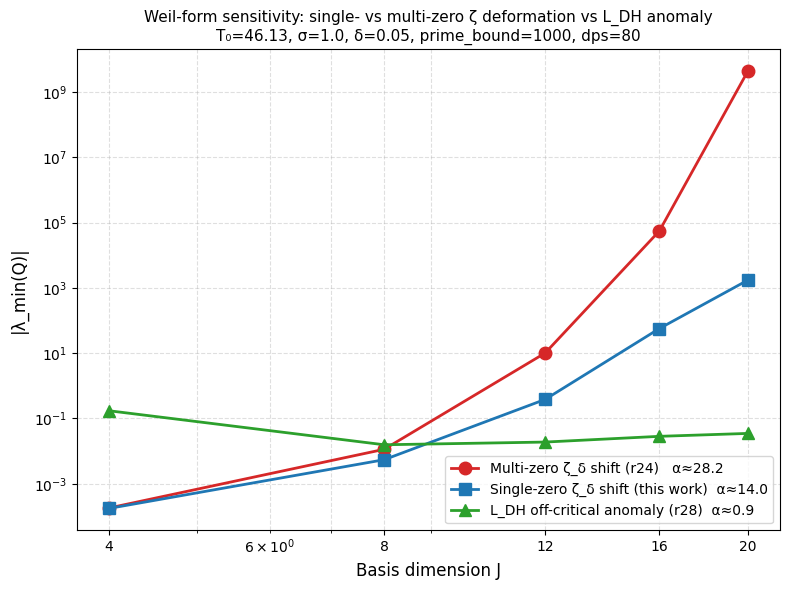

In [17]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6))

Js = np.array(J_values)
ax.loglog(Js, np.abs(zd_multi), 'o-', color='C3', lw=2, ms=9, label=f'Multi-zero ζ_δ shift (r24) α≈{a_m:.1f}')
ax.loglog(Js, np.abs(zd_single), 's-', color='C0', lw=2, ms=9, label=f'Single-zero ζ_δ shift (this work) α≈{a_s:.1f}')
ax.loglog(Js, np.abs(ldh), '^-', color='C2', lw=2, ms=9, label=f'L_DH off-critical anomaly (r28) α≈{a_l:.1f}')

ax.set_xlabel('Basis dimension J', fontsize=12)
ax.set_ylabel('|λ_min(Q)|', fontsize=12)
ax.set_title('Weil-form sensitivity: single- vs multi-zero ζ deformation vs L_DH anomaly\n'
 'T₀=46.13, σ=1.0, δ=0.05, prime_bound=1000, dps=80', fontsize=11)
ax.set_xticks(Js)
ax.set_xticklabels([str(j) for j in Js])
ax.grid(True, which='both', ls='--', alpha=0.4)
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('weil_single_vs_multi_vs_ldh.png', dpi=140)
plt.show()
